In [1]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os

In [2]:
manhattan_shapes = pd.read_csv('./output/manhattan_shapes.csv')
manhattan_shapes['ZIP Code'] = manhattan_shapes['ZIP Code'].astype(str)

In [3]:
education_2023 = pd.read_csv(os.path.join('education', 'education_2023.csv'))
split_name = education_2023['NAME'].str.split(' ')

education_2023['ZIP Code'] = split_name.str[-1]

C:\Users\Trevor Semeraro\AppData\Local\Temp\ipykernel_8740\2956703492.py:1: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549

In [4]:
gdf_with_education = manhattan_shapes.merge(education_2023, left_on='ZIP Code', right_on='ZIP Code', how='left')

In [5]:
from shapely import wkt
import geopandas as gpd

# Convert the 'geometry' column from WKT text to real shapely objects
gdf_with_education['geometry'] = gdf_with_education['geometry'].apply(wkt.loads)

# Now make it a GeoDataFrame
gdf_with_education = gpd.GeoDataFrame(gdf_with_education, geometry='geometry')

# (Optional but good practice) Set the CRS
gdf_with_education.set_crs(epsg=4326, inplace=True)  # WGS84 latitude/longitude

,pop_est,geometry,ZIP Code,SAFMR 1BR,GEO_ID,NAME,S1501_C01_001E,S1501_C01_001M,S1501_C01_002E,S1501_C01_002M,...,S1501_C06_060M,S1501_C06_061E,S1501_C06_061M,S1501_C06_062E,S1501_C06_062M,S1501_C06_063E,S1501_C06_063M,S1501_C06_064E,S1501_C06_064M,Unnamed: 770
0,23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",10001,3220.0,860Z200US10001,ZCTA5 10001,3033,389,37,53,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
1,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",10002,2210.0,860Z200US10002,ZCTA5 10002,5978,783,533,277,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
2,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",10003,3500.0,860Z200US10003,ZCTA5 10003,13489,798,93,71,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
3,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",10026,2270.0,860Z200US10026,ZCTA5 10026,2765,667,295,154,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
4,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",10004,3320.0,860Z200US10004,ZCTA5 10004,89,72,14,23,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
5,8831.0,"POLYGON ((-74.00783 40.70309, -74.00786 40.703...",10005,3500.0,860Z200US10005,ZCTA5 10005,1070,506,8,17,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
6,3454.0,"POLYGON ((-74.01251 40.70677, -74.01325 40.705...",10006,3500.0,860Z200US10006,ZCTA5 10006,709,599,0,13,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
7,7023.0,"POLYGON ((-74.00998 40.70981, -74.01123 40.710...",10007,2880.0,860Z200US10007,ZCTA5 10007,634,435,32,28,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
8,57925.0,"POLYGON ((-73.98864 40.72293, -73.98859 40.723...",10009,2450.0,860Z200US10009,ZCTA5 10009,4659,866,285,184,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
9,33730.0,"POLYGON ((-73.97979 40.73496, -73.97988 40.735...",10010,2840.0,860Z200US10010,ZCTA5 10010,4069,525,80,101,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN


In [6]:
# Define a threshold for "mostly" (e.g., 90% or more (X))
threshold = 0.9

# Find columns where most or all values are "(X)"
cols_to_drop = [
    col for col in gdf_with_education.columns
    if (gdf_with_education[col] == "(X)").mean() >= threshold
]

# Drop those columns
gdf_with_education = gdf_with_education.drop(columns=cols_to_drop)
constant = ['ZIP Code', 'geometry',]
sections = ['S1501_C02_002E', 'S1501_C02_003E', 'S1501_C02_004E','S1501_C02_005E']
section_labels = [
    'less than highschool graduate',
    'high school graduate',
    'some college or associate degree',
    'bachelor\'s degree or higher'
]
# only keep columns in sections
gdf_with_education = gdf_with_education[gdf_with_education.columns[gdf_with_education.columns.isin(sections + constant)]]

# convert all columns in sections to numeric
gdf_with_education[sections] = gdf_with_education[sections].apply(pd.to_numeric, errors='coerce')

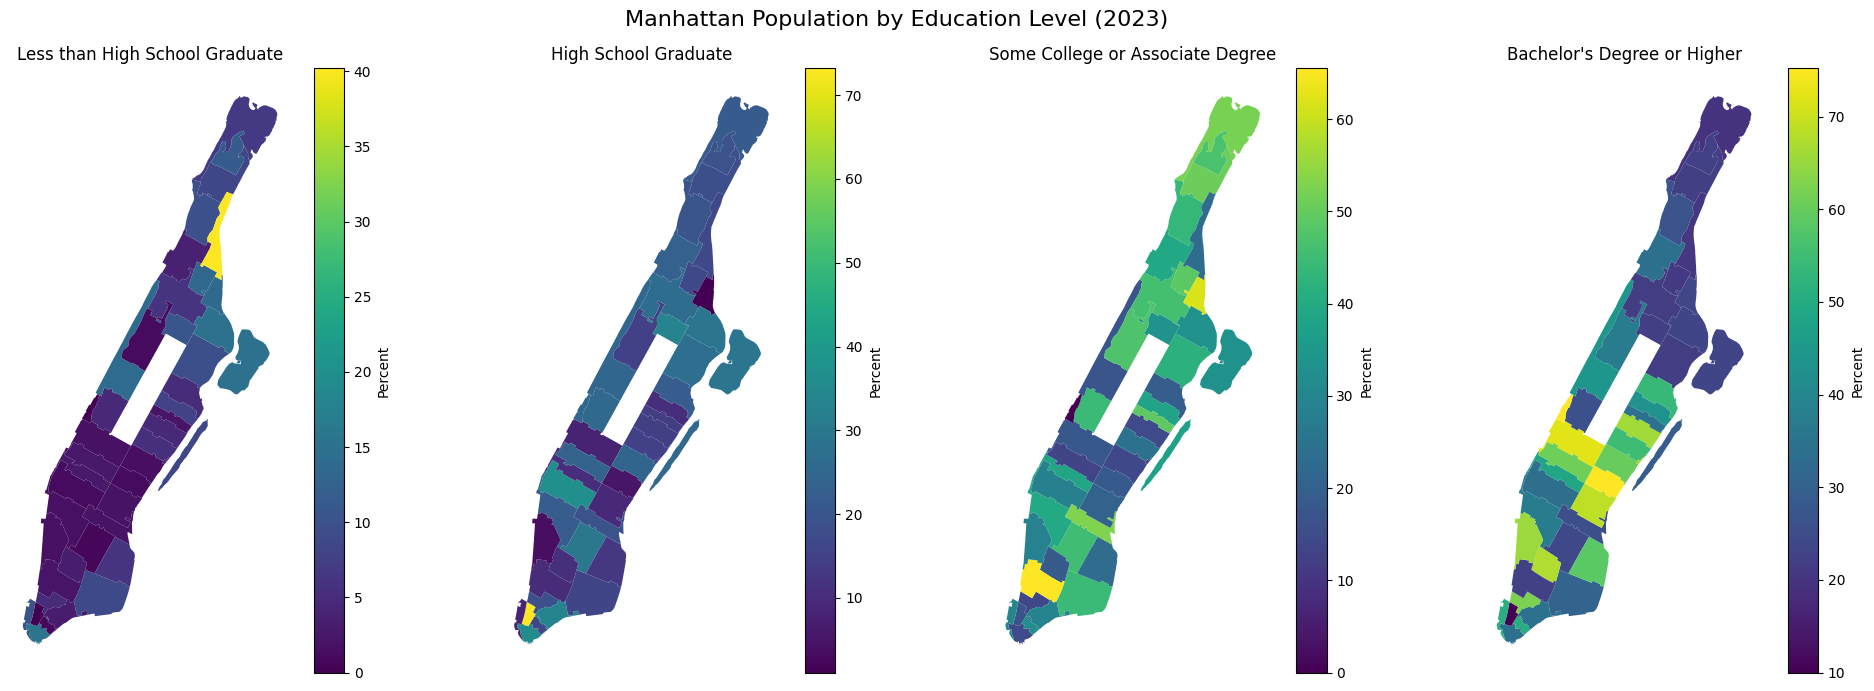

In [9]:
cmap = plt.cm.viridis
fig, axes = plt.subplots(1, 4, figsize=(20, 7))

fig.suptitle("Manhattan Population by Education Level (2023)", fontsize=16)

titles = [
    "Less than High School Graduate",
    "High School Graduate",
    "Some College or Associate Degree",
    "Bachelor's Degree or Higher"
]

for i, (ax, section) in enumerate(zip(axes, sections)):
    gdf_with_education.plot(
        ax=ax,
        column=section,
        cmap=cmap,
        legend=True,
        legend_kwds={'label': "Percent", 'orientation': "vertical"}
    )
    ax.set_title(f"{titles[i]}")
    ax.axis('off')  # turn off axes for cleaner map look

plt.tight_layout()
plt.show()

In [8]:
gdf_with_education.to_csv('./output/education.csv', index=False)